In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg
import pygtc

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
fid_tot = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/fid.h5", "withering", 0)
fid_rvir = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/fid.h5", "Rvir", 0)
fid = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/fid.h5", "artificial", 0)

alpha_up = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/alpha_up.h5", "artificial", 0)
alpha_down = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/alpha_down.h5", "artificial", 0)
DF_up = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/DF_up.h5", "artificial", 0)
DF_down = jsm_ancillary.load_bolshoi("../../data/bolshoi_rep/DF_down.h5", "artificial", 0)

In [5]:
bolshoi = pd.read_csv("../../data/summary_tabs/bolshoi_full.csv")
bin_min = 13.1
bin_max = 13.3
subsample = bolshoi[(bolshoi["logMvir"] > bin_min) & (bolshoi["logMvir"] < bin_max)]
bolshoi = subsample[["logMvir", "log1pz50", "logc", "logNsub", "logfsub"]]

In [6]:
def plot_corner_with_corr(
    chains,
    base_labels=None,
    add_corr=True,
    corr_func=None,
    z_key="log1pz50",
    c_key="logc",
    nsub_key="logNsub",
    colors=None,
    **kwargs
):
    """
    Lightweight wrapper around pygtc.plotGTC.

    Any additional keyword arguments (e.g. ranges, paramNames, etc.)
    are passed directly to pygtc.
    """

    if base_labels is None:
        base_labels = [f"Chain {i}" for i in range(len(chains))]

    chainLabels = []
    for chain, label in zip(chains, base_labels):

        if add_corr and corr_func is not None:
            rho_z = corr_func(chain[nsub_key], chain[z_key])
            rho_c = corr_func(chain[nsub_key], chain[c_key])

            label = (
                f"{label}: \n"
                f"$\\rho_z$={rho_z:.2f}, "
                f"$\\rho_c$={rho_c:.2f}"
            )

        chainLabels.append(label)

    return pygtc.plotGTC(
        chains=chains,
        chainLabels=chainLabels,
        smoothingKernel=2,
        figureSize=10,
        customTickFont={'family': 'Times', 'size': 12},
        customLegendFont={'family': 'Times', 'size': 12},
        customLabelFont={'family': 'Times', 'size': 12},
        mathTextFontSet=None,
        panelSpacing='loose',
        colorsOrder=colors,
        **kwargs  # <-- this is the key
    )

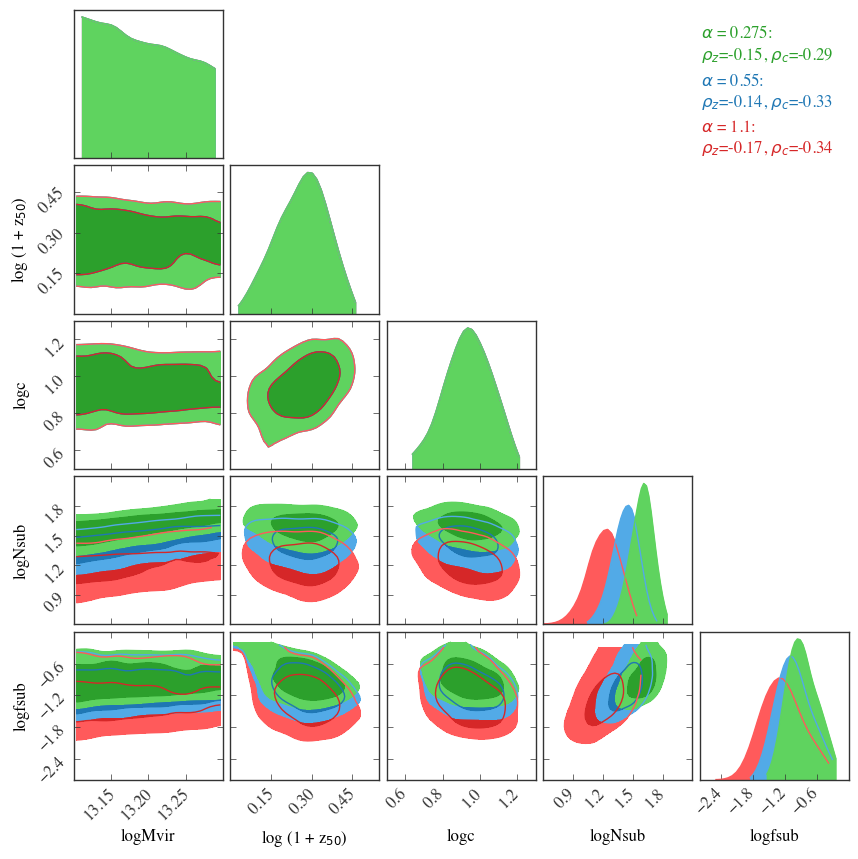

In [7]:
corner_comp = plot_corner_with_corr(
    chains=[alpha_down, fid, alpha_up],
    base_labels=["$\\alpha$ = 0.275", "$\\alpha$ = 0.55", "$\\alpha$ = 1.1"],
    corr_func=jsm_stats.correlation,
    colors=["greens", "blues", "reds"],
    paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
    paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]],
)

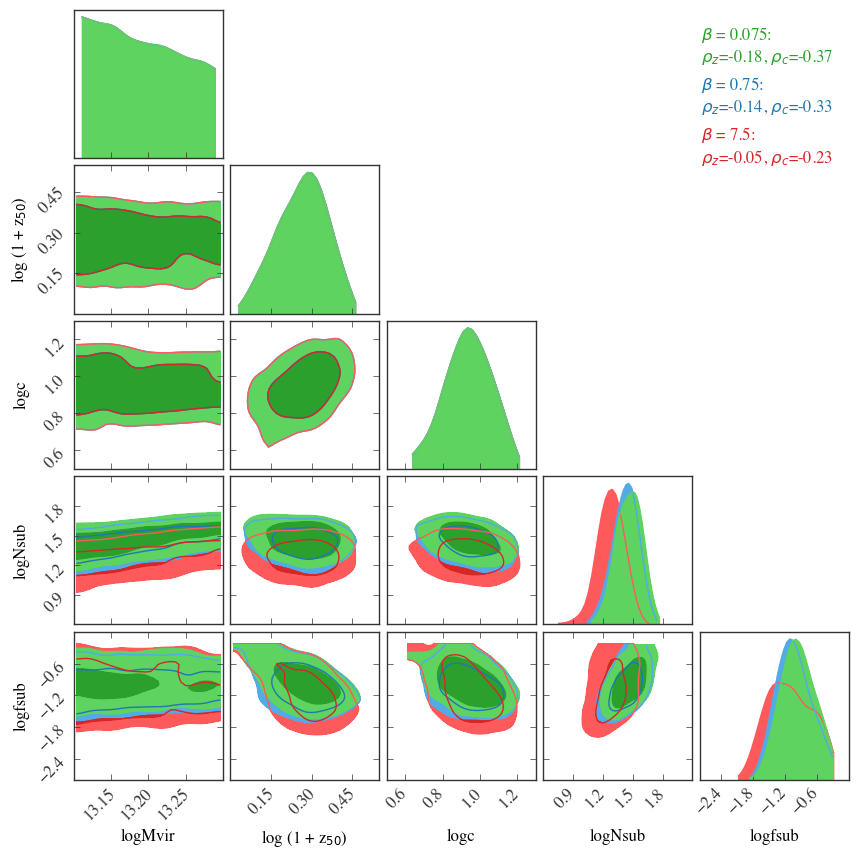

In [8]:
corner_comp = plot_corner_with_corr(
    chains=[DF_down, fid, DF_up],
    base_labels=["$\\beta$ = 0.075", "$\\beta$ = 0.75", "$\\beta$ = 7.5"],
    corr_func=jsm_stats.correlation,
    colors=["greens", "blues", "reds"],
    paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
    paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
)

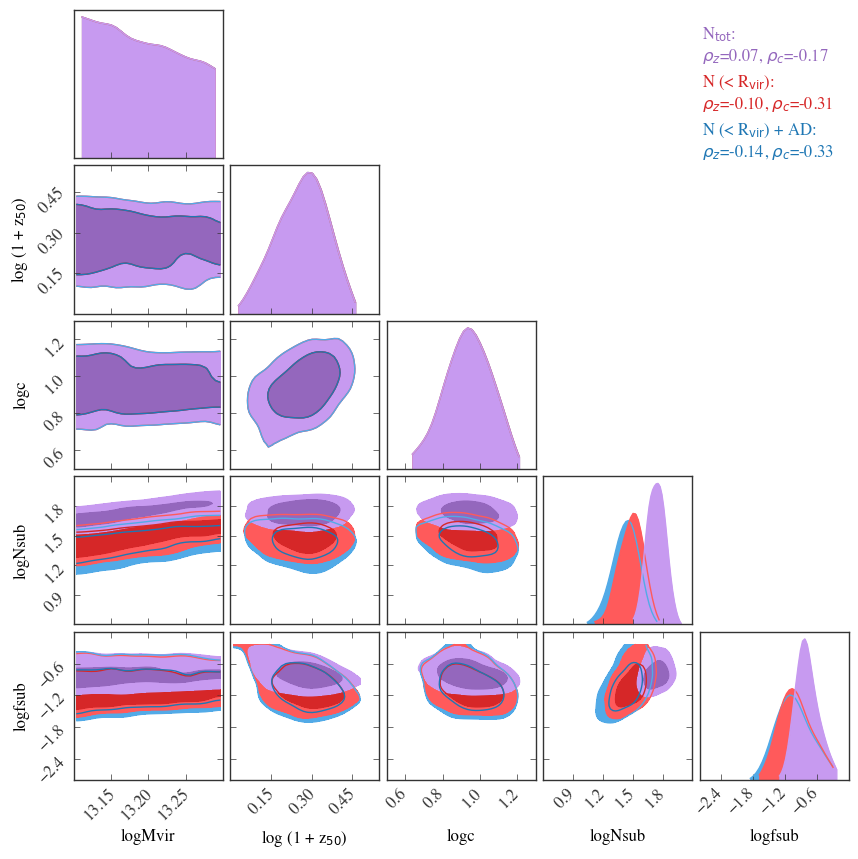

In [9]:
corner_comp = plot_corner_with_corr(
    chains=[fid_tot, fid_rvir, fid],
    base_labels=["N$_{\\rm tot}$", "N (< R$_{\\rm vir}$)",  "N (< R$_{\\rm vir}$) + AD"],
    corr_func=jsm_stats.correlation,
    colors=["purples", "reds", "blues"],
    paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
    paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
)

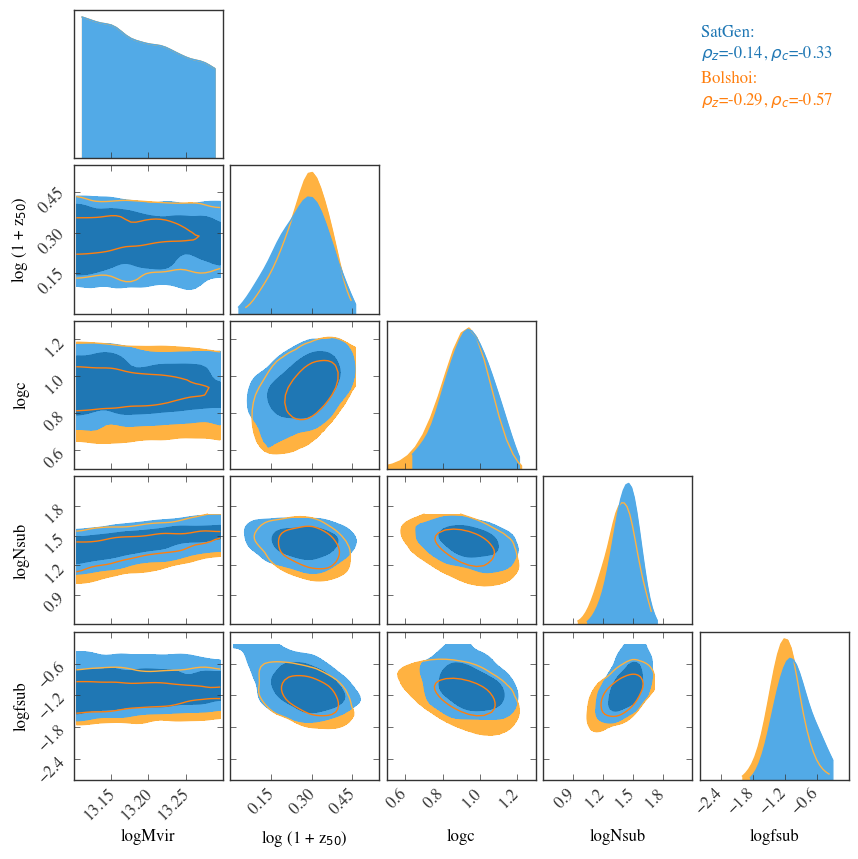

In [10]:
corner_comp = plot_corner_with_corr(
    chains=[fid, bolshoi],
    base_labels=["SatGen", "Bolshoi"],
    corr_func=jsm_stats.correlation,
    colors=["blues", "oranges"],
    paramNames=["logMvir", "log (1 + z$_{50}$)", "logc", "logNsub", "logfsub"],
    paramRanges=[[13.1, 13.3], [0.0, 0.55], [0.5, 1.3], [0.6, 2.1], [-2.8, 0]]
)

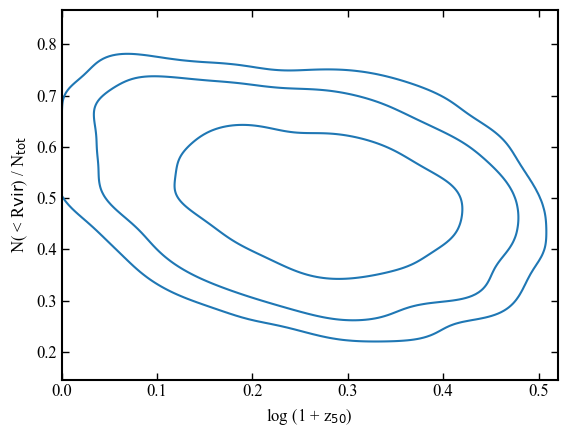

In [11]:
sns.kdeplot(x=fid["log1pz50"], y=(10**fid["logNsub"])/(10**fid_tot["logNsub"]), levels=levelz, bw_adjust=1.2)
plt.xlim(0, 0.52)
plt.xlabel("log (1 + z$_{50}$)")
plt.ylabel("N( < R${\\rm vir}$) / N$_{\\rm tot}$")
plt.show()

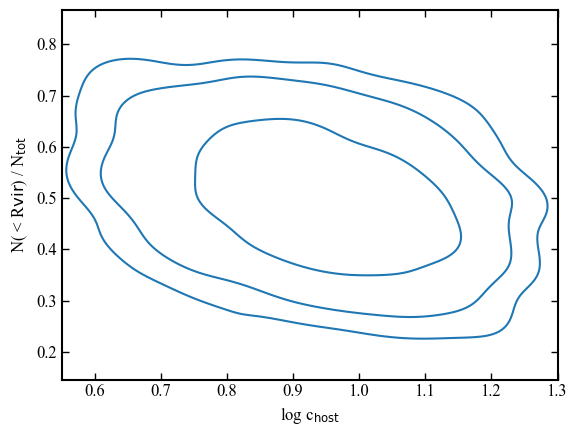

In [12]:
sns.kdeplot(x=fid["logc"], y=(10**fid["logNsub"])/(10**fid_tot["logNsub"]), levels=levelz, bw_adjust=1.2)
plt.xlim(0.55, 1.3)
plt.xlabel("log c$_{\\rm host}$")
plt.ylabel("N( < R${\\rm vir}$) / N$_{\\rm tot}$")
plt.show()

In [37]:
def correlation_convergence_linear(
    df,
    xcol="logNsub",
    ycols=("log1pz50", "logc"),
    step=50,
    n_boot=50,
    method="spearman",
    random_state=42
):
    rng = np.random.default_rng(random_state)

    N = len(df)
    sample_sizes = np.arange(step, N + 1, step)

    # ensure full dataset is included
    if sample_sizes[-1] != N:
        sample_sizes = np.append(sample_sizes, N)

    results = []

    for n in sample_sizes:
        for ycol in ycols:
            corrs = []

            for _ in range(n_boot):
                sample = df.sample(
                    n=n,
                    replace=False,
                    random_state=rng.integers(1e9)
                )

                corrs.append(sample[xcol].corr(sample[ycol], method=method))

            results.append({
                "sample_size": n,
                "ycol": ycol,
                "mean_corr": np.mean(corrs),
                "std_corr": np.std(corrs)
            })

    return pd.DataFrame(results)

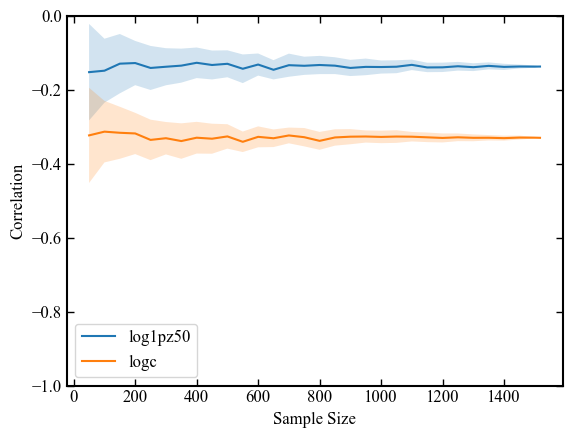

In [38]:
df_corr = correlation_convergence_linear(fid)

fig, ax = plt.subplots()

for ycol in df_corr["ycol"].unique():
    sub = df_corr[df_corr["ycol"] == ycol]

    ax.plot(sub["sample_size"], sub["mean_corr"], label=ycol)
    ax.fill_between(
        sub["sample_size"],
        sub["mean_corr"] - sub["std_corr"],
        sub["mean_corr"] + sub["std_corr"],
        alpha=0.2
    )

ax.set_xlabel("Sample Size")
ax.set_ylabel("Correlation")
ax.legend()
ax.set_ylim(-1, 0)

plt.show()

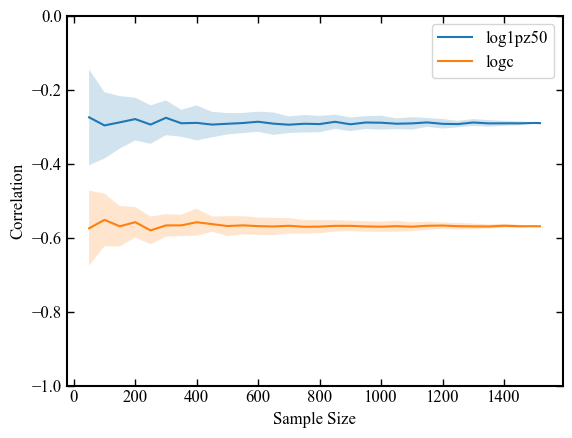

In [39]:
df_corr = correlation_convergence_linear(bolshoi)

fig, ax = plt.subplots()

for ycol in df_corr["ycol"].unique():
    sub = df_corr[df_corr["ycol"] == ycol]

    ax.plot(sub["sample_size"], sub["mean_corr"], label=ycol)
    ax.fill_between(
        sub["sample_size"],
        sub["mean_corr"] - sub["std_corr"],
        sub["mean_corr"] + sub["std_corr"],
        alpha=0.2
    )

ax.set_xlabel("Sample Size")
ax.set_ylabel("Correlation")
ax.legend()
ax.set_ylim(-1, 0)

plt.show()